In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import matplotlib.patches as mpatches

In [2]:
df = pd.read_csv("csvs/us_leagues_goat_scores.csv")

In [3]:
## Adding Necessary Columns

df['log(GOAT)'] = df.apply(lambda row: math.log(row['GOAT_Score']), axis  = 1)

df['log(WOAT)'] = df.apply(lambda row: math.log(row['WOAT_Score']), axis  = 1)

df['formatted_team_name'] = df.apply(lambda row: str(row['Season']) + ' ' + row['Team'], axis = 1)

df['color'] = df.apply(lambda row: "orange" if row['League'] == 'NBA' else 'blue', axis = 1)

In [4]:
df

,Unnamed: 0,League,Season,Team,Sequence,GOAT_Score,WOAT_Score,log(GOAT),log(WOAT),formatted_team_name,color
0,0,NBA,2015,Orlando Magic,"[0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...",1.081476,8.918835,0.078327,2.188165,2015 Orlando Magic,orange
1,1,NBA,2015,Houston Rockets,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",1.838500,1.838500,0.608950,0.608950,2015 Houston Rockets,orange
2,2,NBA,2015,Oklahoma City Thunder,"[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, ...",756.861070,1.000611,6.629180,0.000610,2015 Oklahoma City Thunder,orange
3,3,NBA,2015,Sacramento Kings,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",1.030826,20.611988,0.030360,3.025873,2015 Sacramento Kings,orange
4,4,NBA,2015,Utah Jazz,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...",1.588124,2.192606,0.462554,0.785091,2015 Utah Jazz,orange
...,...,...,...,...,...,...,...,...,...,...,...
3494,3494,NBA,1991,Boston Celtics,"[1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, ...",56.751370,1.010013,4.038680,0.009963,1991 Boston Celtics,orange
3495,3495,NBA,1991,Los Angeles Lakers,"[0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...",2.700320,1.409557,0.993370,0.343275,1991 Los Angeles Lakers,orange
3496,3496,NBA,1991,Denver Nuggets,"[0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, ...",1.000044,9010.468746,0.000044,9.106142,1991 Denver Nuggets,orange
3497,3497,NBA,1991,Dallas Mavericks,"[0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, ...",1.000006,61886.690905,0.000006,11.033060,1991 Dallas Mavericks,orange


In [5]:
df_NBA = df[df["League"] == "NBA"]

df_MLB = df[df["League"] == "MLB"]

In [6]:
df_NBA.nlargest(10, "GOAT_Score")[["Team", "Season", "League", "GOAT_Score"]]

,Team,Season,League,GOAT_Score
6,Golden State Warriors,2015,NBA,1.452710e+13
3163,Chicago Bulls,1995,NBA,1.956068e+12
2880,Chicago Bulls,1996,NBA,8.865848e+09
2558,Oklahoma City Thunder,2024,NBA,1.762217e+09
20,San Antonio Spurs,2015,NBA,3.804222e+08
2395,Golden State Warriors,2016,NBA,3.804222e+08
2634,Los Angeles Lakers,1999,NBA,3.804222e+08
2744,Boston Celtics,1985,NBA,3.804222e+08
2980,Dallas Mavericks,2006,NBA,3.804222e+08
3017,Golden State Warriors,2014,NBA,3.804222e+08


In [7]:
df_MLB.nlargest(10, "GOAT_Score")[["Team", "Season", "League", "GOAT_Score"]]

,Team,Season,League,GOAT_Score
1610,Seattle Mariners,2001,MLB,5.449882e+07
484,Cleveland Indians,1954,MLB,4.905777e+07
55,New York Yankees,1927,MLB,1.907257e+07
1514,New York Yankees,1998,MLB,8.867464e+06
120,Philadelphia Athletics,1931,MLB,3.780815e+06
247,New York Yankees,1939,MLB,2.668802e+06
135,New York Yankees,1932,MLB,1.887978e+06
88,Philadelphia Athletics,1929,MLB,8.091980e+05
2229,Los Angeles Dodgers,2022,MLB,7.208491e+05
300,St. Louis Cardinals,1942,MLB,5.903959e+05


In [8]:
top_goat_log = df.nlargest(20, "log(GOAT)")

top_woat_log = df.nlargest(20, "log(WOAT)")

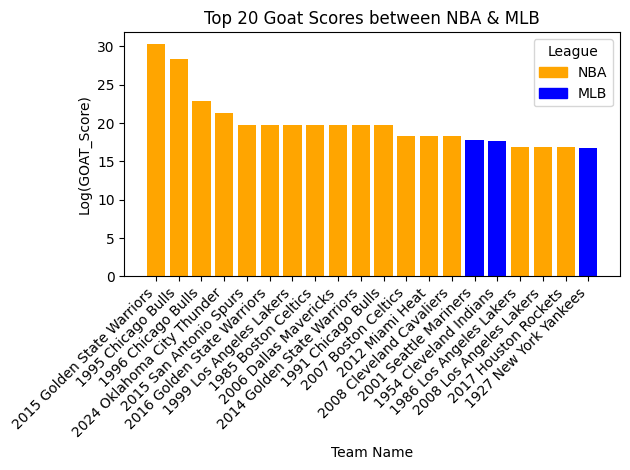

In [9]:
## Plots top 20 GOAT Scores across US Leagues

plt.bar(top_goat_log['formatted_team_name'], top_goat_log['log(GOAT)'], color=top_goat_log['color'])

plt.xlabel("Team Name")
plt.ylabel("Log(GOAT_Score)")
plt.title("Top 20 Goat Scores between NBA & MLB")

plt.xticks(rotation = 45, ha="right")

handles = [
    mpatches.Patch(color="orange", label="NBA"),
    mpatches.Patch(color="blue", label="MLB")
]

plt.legend(handles=handles, title="League")
plt.tight_layout()
plt.show()

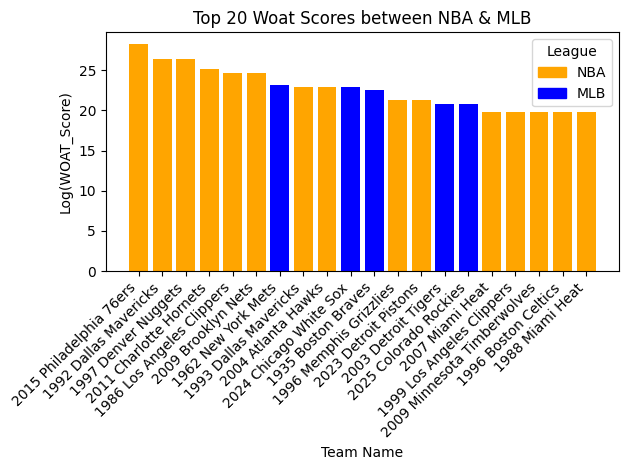

In [10]:
## Plots top 20 WOAT Scores across US Leagues

plt.bar(top_woat_log['formatted_team_name'], top_woat_log['log(WOAT)'], color=top_woat_log['color'])

plt.xlabel("Team Name")
plt.ylabel("Log(WOAT_Score)")
plt.title("Top 20 Woat Scores between NBA & MLB")

plt.xticks(rotation = 45, ha="right")

handles = [
    mpatches.Patch(color="orange", label="NBA"),
    mpatches.Patch(color="blue", label="MLB")
]

plt.legend(handles=handles, title="League")
plt.tight_layout()
plt.show()

In [11]:
## May need to add weights to MLB, since rarities are less likely to occur in a season 2x as long as the NBA.

Text(0.5, 1.0, 'Logarithm of NBA Goat Scores Distribution')

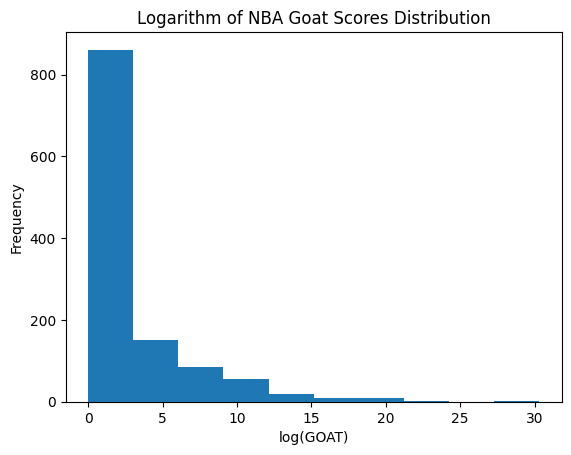

In [12]:
## Histograms

plt.hist(df_NBA['log(GOAT)'])

plt.ylabel("Frequency")
plt.xlabel("log(GOAT)")
plt.title("Logarithm of NBA Goat Scores Distribution")

Text(0.5, 1.0, 'Logarithm of MLB Goat Scores Distribution')

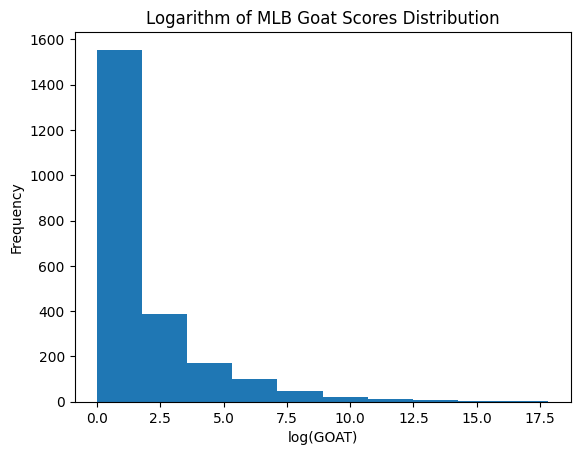

In [13]:
plt.hist(df_MLB['log(GOAT)'])

plt.ylabel("Frequency")
plt.xlabel("log(GOAT)")
plt.title("Logarithm of MLB Goat Scores Distribution")

In [14]:
df_NBA.nlargest(10, "GOAT_Score")

,Unnamed: 0,League,Season,Team,Sequence,GOAT_Score,WOAT_Score,log(GOAT),log(WOAT),formatted_team_name,color
6,6,NBA,2015,Golden State Warriors,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1.452710e+13,1.0,30.307037,8.215650e-15,2015 Golden State Warriors,orange
3163,3163,NBA,1995,Chicago Bulls,"[1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, ...",1.956068e+12,1.0,28.301958,6.883383e-14,1995 Chicago Bulls,orange
2880,2880,NBA,1996,Chicago Bulls,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, ...",8.865848e+09,1.0,22.905472,2.053957e-11,1996 Chicago Bulls,orange
2558,2558,NBA,2024,Oklahoma City Thunder,"[1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, ...",1.762217e+09,1.0,21.289839,1.127924e-10,2024 Oklahoma City Thunder,orange
20,20,NBA,2015,San Antonio Spurs,"[0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, ...",3.804222e+08,1.0,19.756792,5.674670e-10,2015 San Antonio Spurs,orange
2395,2395,NBA,2016,Golden State Warriors,"[0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",3.804222e+08,1.0,19.756792,5.674670e-10,2016 Golden State Warriors,orange
2634,2634,NBA,1999,Los Angeles Lakers,"[1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, ...",3.804222e+08,1.0,19.756792,5.674670e-10,1999 Los Angeles Lakers,orange
2744,2744,NBA,1985,Boston Celtics,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, ...",3.804222e+08,1.0,19.756792,5.674670e-10,1985 Boston Celtics,orange
2980,2980,NBA,2006,Dallas Mavericks,"[0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",3.804222e+08,1.0,19.756792,5.674670e-10,2006 Dallas Mavericks,orange
3017,3017,NBA,2014,Golden State Warriors,"[1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...",3.804222e+08,1.0,19.756792,5.674670e-10,2014 Golden State Warriors,orange
